<a href="https://colab.research.google.com/github/OmkarPujeri/Credit-Card-Fraud-Detection/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection
## Objective
Build a fraud detection pipeline on 284,807 real credit card transactions
(0.17% fraud). Since accuracy is misleading on imbalanced data, ROC-AUC
and Recall are used as primary metrics.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
df = pd.read_csv('creditcard.csv')

print(df.shape)
print(df.isnull().sum())
print(df.dtypes)
df.head()

(284807, 31)
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Exploratory Data Analysis
The dataset is severely imbalanced, 492 fraudulent transactions out of 284,807.
A naive classifier that predicts "legit" every time achieves 99.8% accuracy,
which is why accuracy alone cannot be trusted here.

Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


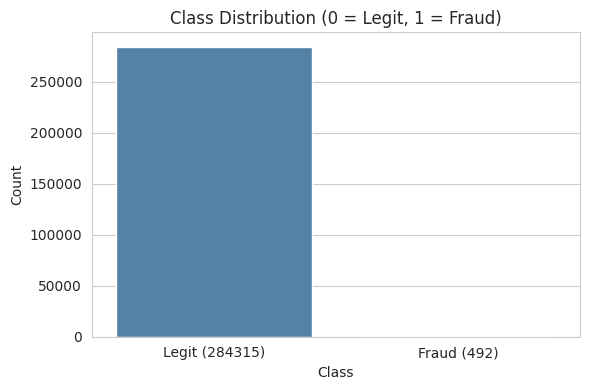

In [4]:
# Class distribution
fraud_count = df['Class'].value_counts()
print(fraud_count)
print(f"\nFraud percentage: {fraud_count[1]/len(df)*100:.4f}%")

# Plot it
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['steelblue', 'crimson'])
plt.title('Class Distribution (0 = Legit, 1 = Fraud)')
plt.xticks([0, 1], ['Legit (284315)', 'Fraud (492)'])
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

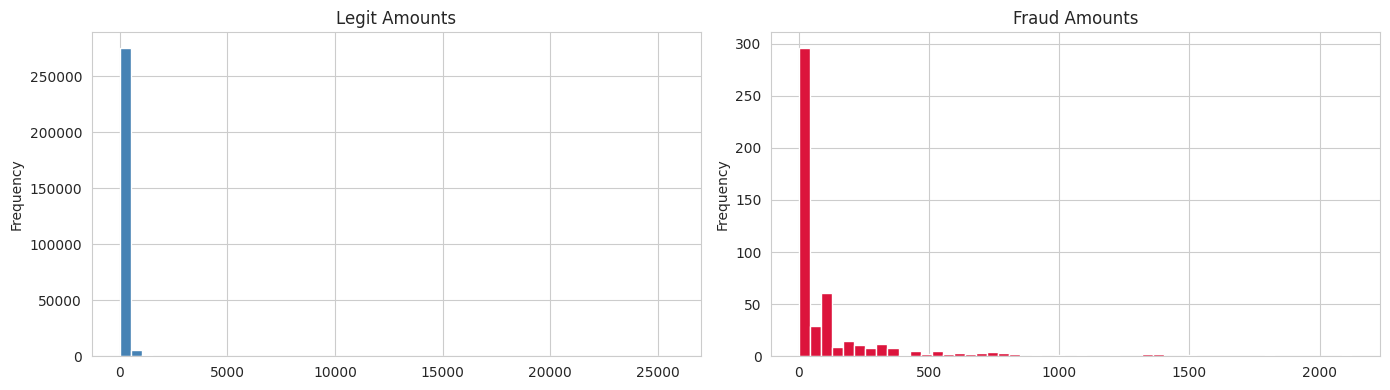

Avg legit amount: 88.29
Avg fraud amount: 122.21


In [5]:
# Transaction amount: fraud vs legit
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[df['Class'] == 0]['Amount'].plot(kind='hist', bins=50, ax=axes[0],
                                     color='steelblue', title='Legit Amounts')
df[df['Class'] == 1]['Amount'].plot(kind='hist', bins=50, ax=axes[1],
                                     color='crimson', title='Fraud Amounts')
plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150)
plt.show()

print("Avg legit amount:", df[df['Class']==0]['Amount'].mean().round(2))
print("Avg fraud amount:", df[df['Class']==1]['Amount'].mean().round(2))

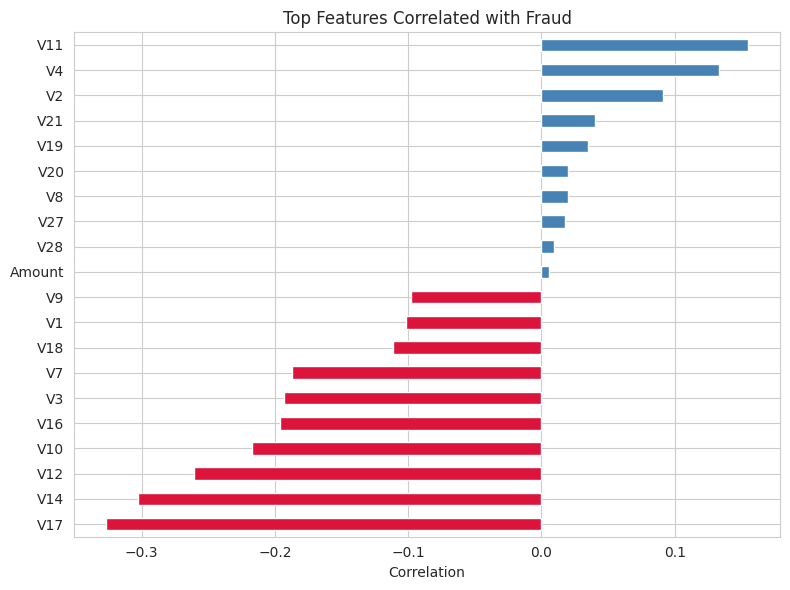

In [6]:
# Correlation heatmap of top features correlated with fraud
correlations = df.corr()['Class'].drop('Class').sort_values()
top_features = pd.concat([correlations.head(10), correlations.tail(10)])

plt.figure(figsize=(8, 6))
top_features.plot(kind='barh', color=['crimson' if x < 0 else 'steelblue'
                                        for x in top_features])
plt.title('Top Features Correlated with Fraud')
plt.xlabel('Correlation')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150)
plt.show()

## 2. Preprocessing
V1-V28 are already PCA-transformed by the dataset authors for confidentiality.
We scale Amount and Time to bring them to the same range as the PCA features.

In [7]:
# Scale Amount and Time (V1-V28 are already PCA-transformed by dataset authors)
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time']   = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop originals
df.drop(['Amount', 'Time'], axis=1, inplace=True)

# Features and target
X = df.drop('Class', axis=1)
y = df['Class']

print("Features shape:", X.shape)

Features shape: (284807, 30)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size: {X_train.shape[0]} | Fraud in train: {y_train.sum()}")
print(f"Test size:  {X_test.shape[0]}  | Fraud in test:  {y_test.sum()}")

Train size: 227845 | Fraud in train: 394
Test size:  56962  | Fraud in test:  98


## 3. Handling Class Imbalance with SMOTE
SMOTE (Synthetic Minority Oversampling Technique) generates synthetic fraud
samples in the training set only. Applying it to test data would constitute
data leakage and inflate results artificially.

In [9]:
print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE: ", pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE:  {0: 227451, 1: 227451}


## 4. Model Training
Three models are compared: Logistic Regression (baseline), Random Forest,
and XGBoost. All trained on the SMOTE-balanced training set.

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                          scale_pos_weight=1, eval_metric='logloss')
}

trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_sm, y_train_sm)
    trained_models[name] = model
    print(f"  Done.")

Training Logistic Regression...
  Done.
Training Random Forest...
  Done.
Training XGBoost...
  Done.


## 5. Evaluation
Primary metric: ROC-AUC. Secondary: Recall on fraud class, since missing
a fraud (false negative) is more costly than a false alarm (false positive).

In [11]:
results = {}

for name, model in trained_models.items():
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    roc_auc  = roc_auc_score(y_test, y_pred_prob)
    avg_prec = average_precision_score(y_test, y_pred_prob)

    results[name] = {
        'y_pred': y_pred,
        'y_pred_prob': y_pred_prob,
        'roc_auc': roc_auc,
        'avg_precision': avg_prec
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  ROC-AUC Score:      {roc_auc:.4f}")
    print(f"  Avg Precision:      {avg_prec:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Legit', 'Fraud'])}")


  Logistic Regression
  ROC-AUC Score:      0.9698
  Avg Precision:      0.7249

              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


  Random Forest
  ROC-AUC Score:      0.9688
  Avg Precision:      0.8675

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962


  XGBoost
  ROC-AUC Score:      0.9792
  Avg Precision:      0.8774

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fr

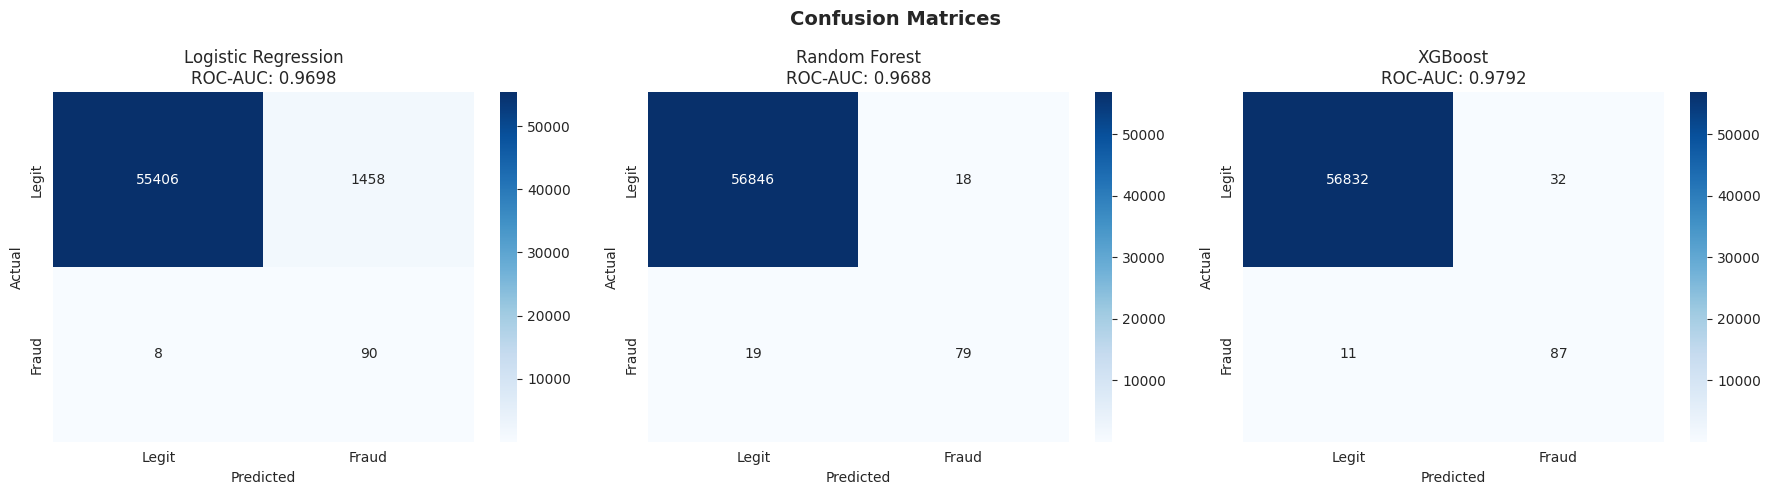

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'])
    ax.set_title(f'{name}\nROC-AUC: {res["roc_auc"]:.4f}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

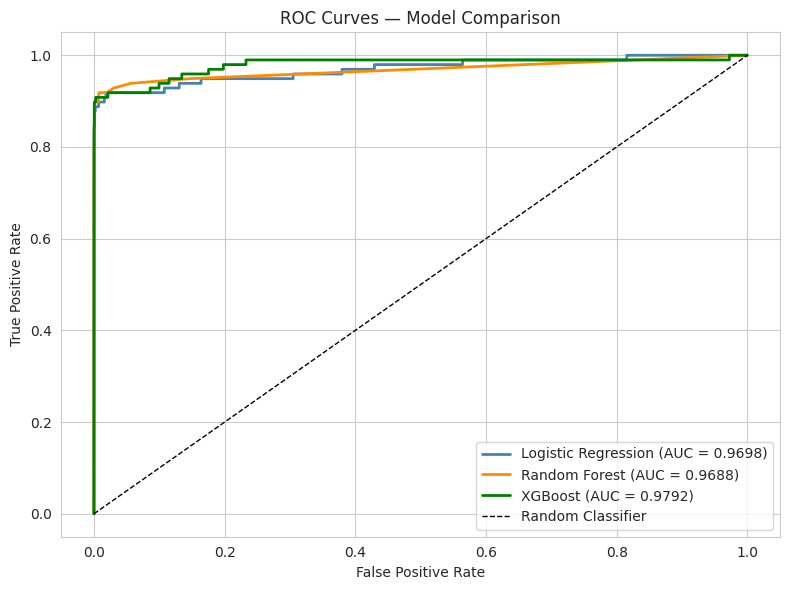

In [13]:
plt.figure(figsize=(8, 6))

colors = ['steelblue', 'darkorange', 'green']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_pred_prob'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{name} (AUC = {res['roc_auc']:.4f})")

plt.plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

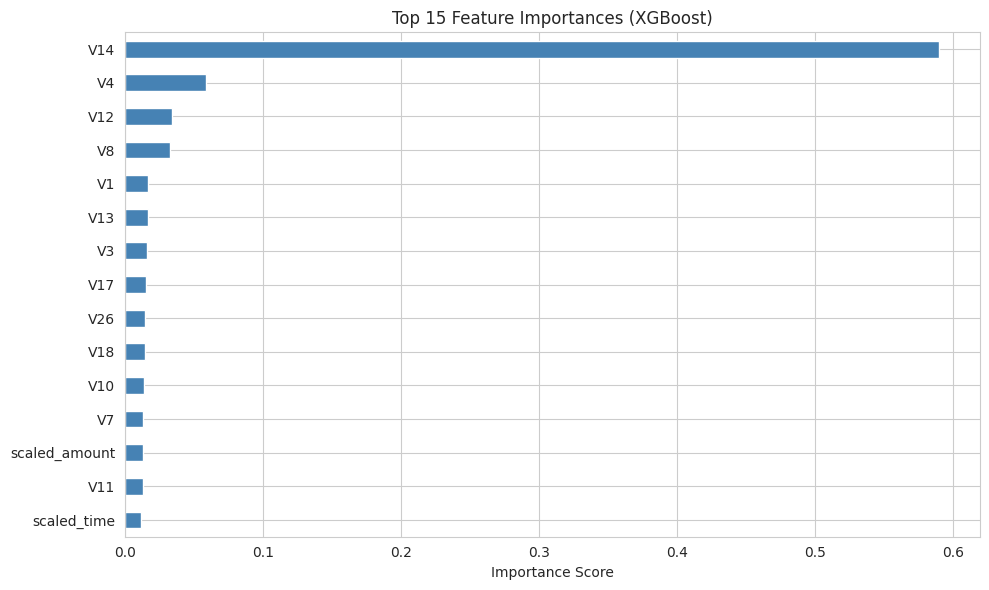

In [14]:
xgb_model = trained_models['XGBoost']
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top15.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

## 6. Conclusion
| Model               | ROC-AUC | Fraud Recall | Fraud Precision |
|---------------------|---------|--------------|-----------------|
| Logistic Regression | 0.9698  | 92%          | 6%              |
| Random Forest       | 0.9688  | 81%          | 81%             |
| XGBoost             | 0.9792  | 89%          | 73%             |

XGBoost achieved the best ROC-AUC of 0.9792. Logistic Regression had the
highest recall (92%) but near-zero precision (6%), generating excessive false
positives, unusable in production. XGBoost offers the best tradeoff with
89% recall and 73% precision. Feature V14 and V17 were the strongest
predictors per XGBoost feature importances.